# performing linear regression 

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore') 

In [3]:
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 

In [4]:
df = pd.read_csv("canada.csv")
df

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [5]:
X = df[["year"]]
y = df[["per capita income (US$)"]]

In [6]:
X_train , X_test  , y_train, y_test = train_test_split (X,y , test_size= 0.2 , random_state = 42 )


Text(0.5, 1.0, 'HOUSING PRICE YEAR WISE ')

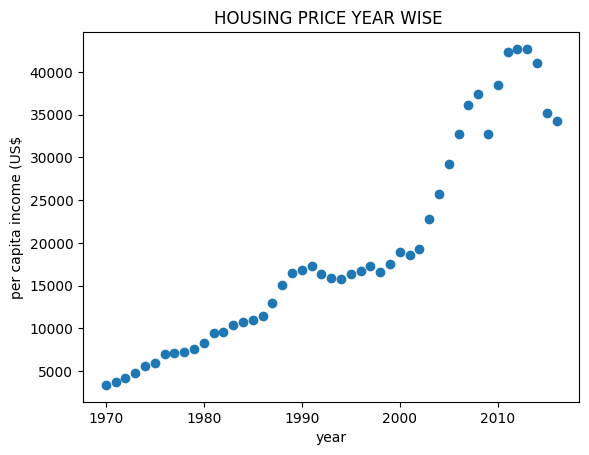

In [7]:
plt.scatter(df["year"] , df["per capita income (US$)"])
plt.xlabel('year')
plt.ylabel('per capita income (US$')
plt.title('HOUSING PRICE YEAR WISE ')


In [8]:
model = LinearRegression()

In [9]:
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = model.predict(X_test)
y_pred

array([[22279.39968245],
       [32061.10983855],
       [21464.25716944],
       [35321.67989059],
       [19833.97214342],
       [29615.68229953],
       [10052.26198731],
       [15758.25957838],
       [ 3531.12188324],
       [20649.11465643]])

In [11]:
pred = model.predict([[2090]])
print(pred)

[[98087.65339228]]


In [12]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error ,root_mean_squared_error 

In [13]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 15147815.5477862


In [14]:
r2 = r2_score(y_test , y_pred)
print("R2" , r2)

R2 0.8751771396846304


# performing logistic regression 

In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [16]:
df = pd.read_csv("healthcare_data.csv")
df

,Age,BMI,Smoker,Children,Blood_Pressure,Medical_Cost
0,25,22,0,0,120,15000
1,28,24,0,1,122,18000
2,30,26,0,2,125,25000
3,32,27,1,1,130,40000
4,35,29,1,2,135,52000
5,38,31,1,3,138,65000
6,40,28,0,2,132,48000
7,42,33,1,2,142,78000
8,45,30,1,1,145,85000
9,48,32,1,3,148,95000


In [17]:
X = df[["Age" , "BMI"]] 
y = df[["Blood_Pressure"]]

In [18]:
model = LogisticRegression()
X_train , X_test , y_train , y_test = train_test_split (X ,y , test_size=0.2, random_state= 42 )
model.fit(X_train , y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_pred = model.predict(X_test)
y_pred

array([128, 138, 128, 128])

In [20]:
pred = model.predict([[37 , 30 ]])
print(pred)

[138]


In [21]:
from sklearn.metrics import  r2_score , mean_absolute_error

In [22]:
r2 = r2_score(y_test , y_pred)
print("R2" , r2)

R2 0.10395314787701315


In [23]:
mae = mean_absolute_error(y_test , y_pred)
print("MAE", mae )

MAE 5.75
